# Flipkart Reviews Sentiment Analysis

Build a simple classifier that reads a product review and predicts whether it is positive or negative. We turn star ratings into labels, convert text to TF-IDF features, and fit logistic regression.

**You will learn:** text cleaning, train/test splits, TF-IDF, logistic regression, confusion matrices, and prediction probabilities.

All code, explanations, and data used by this project are included in this repository.

## 1. Import libraries and set a seed

Pandas loads reviews, scikit-learn turns words into numeric features and trains the classifier, and Seaborn makes the evaluation easy to read.


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

SEED = 42


## 2. Load reviews and make binary labels

The local CSV supplies the reviews. Ratings of 4 or 5 become positive; ratings of 1, 2, or 3 become negative for this simple two-class demo.


In [2]:
DATA_PATH = Path("data/flipkart_reviews.csv") if Path("data/flipkart_reviews.csv").exists() else Path("../data/flipkart_reviews.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Run this notebook from the repository root so data/ is available.")

raw = pd.read_csv(DATA_PATH)
if not {"review", "rating"}.issubset(raw.columns):
    raise ValueError("Expected `review` and `rating` columns.")

reviews = raw.dropna(subset=["review", "rating"]).copy()
reviews["rating"] = pd.to_numeric(reviews["rating"], errors="coerce")
reviews = reviews.dropna(subset=["rating"])
reviews["sentiment"] = (reviews["rating"] >= 4).astype("int32")

print("Usable reviews:", len(reviews))
reviews[["review", "rating", "sentiment"]].head()

Usable reviews: 9976


,review,rating,sentiment
0,It was nice produt. I like it's design a lot. ...,5,1
1,awesome sound....very pretty to see this nd th...,5,1
2,awesome sound quality. pros 7-8 hrs of battery...,4,1
3,I think it is such a good product not only as ...,5,1
4,awesome bass sound quality very good bettary l...,5,1


## 3. Clean only the obvious noise

We lowercase text, remove URLs and boilerplate such as `READ MORE`, and keep ordinary words. Avoid over-cleaning at the start: punctuation, negation, and spelling can carry sentiment.


In [3]:
def clean_review(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"read more", " ", text)
    text = re.sub(r"[^a-z']+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

reviews["clean_text"] = reviews["review"].map(clean_review)
reviews = reviews[reviews["clean_text"].str.len() > 2].reset_index(drop=True)
reviews[["review", "clean_text", "sentiment"]].head(3)


,review,clean_text,sentiment
0,It was nice produt. I like it's design a lot. ...,it was nice produt i like it's design a lot it...,1
1,awesome sound....very pretty to see this nd th...,awesome sound very pretty to see this nd the s...,1
2,awesome sound quality. pros 7-8 hrs of battery...,awesome sound quality pros hrs of battery life...,1


## 4. Check the label balance

A count plot makes class imbalance visible. We will use balanced class weights so the less frequent class still matters during training.


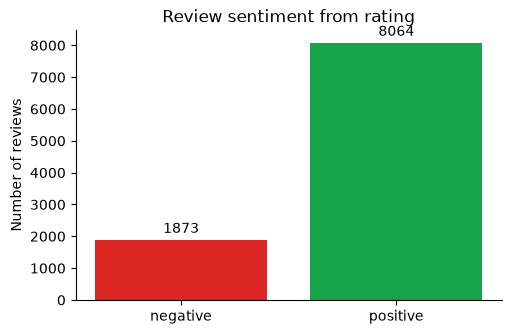

In [4]:
label_counts = reviews["sentiment"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5.5, 3.5))
bars = ax.bar(["negative", "positive"], label_counts.values, color=["#DC2626", "#16A34A"])
ax.bar_label(bars, padding=3)
ax.set(title="Review sentiment from rating", ylabel="Number of reviews")
ax.spines[["top", "right"]].set_visible(False)
plt.show()


## 5. Split reviews before learning the vocabulary

The test set stays untouched until evaluation. Fitting TF-IDF only on training reviews prevents the model from quietly learning which words appear in the test set.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    reviews["clean_text"],
    reviews["sentiment"],
    test_size=0.20,
    random_state=SEED,
    stratify=reviews["sentiment"],
)
print(f"Training reviews: {len(X_train):,}")
print(f"Test reviews:     {len(X_test):,}")


Training reviews: 7,949
Test reviews:     1,988


## 6. Turn words into features and train

TF-IDF gives each review a sparse vector of useful words and short phrases. Logistic regression is a strong, fast baseline for this kind of text classification.


In [6]:
sentiment_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=8_000,
                sublinear_tf=True,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1_000,
                class_weight="balanced",
                random_state=SEED,
            ),
        ),
    ]
)
sentiment_model.fit(X_train, y_train)
print("Model trained.")


Model trained.


## 7. Evaluate unseen reviews

Accuracy is a quick summary. The classification report and confusion matrix show which sentiment is harder for the model to recognize.


Test accuracy: 0.871

              precision    recall  f1-score   support

    negative       0.62      0.81      0.70       375
    positive       0.95      0.89      0.92      1613

    accuracy                           0.87      1988
   macro avg       0.79      0.85      0.81      1988
weighted avg       0.89      0.87      0.88      1988



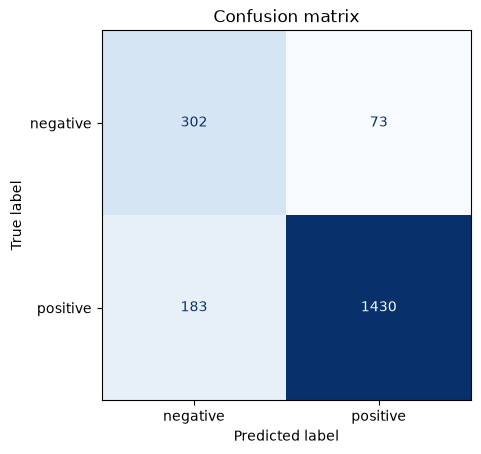

In [7]:
test_predictions = sentiment_model.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, test_predictions):.3f}")
print()
print(classification_report(y_test, test_predictions, target_names=["negative", "positive"]))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["negative", "positive"],
    cmap="Blues",
    colorbar=False,
)
plt.title("Confusion matrix")
plt.show()


## 8. Inspect influential words

Logistic regression assigns a weight to each feature. These terms help explain the model's behavior, but a word's meaning can still change with context.


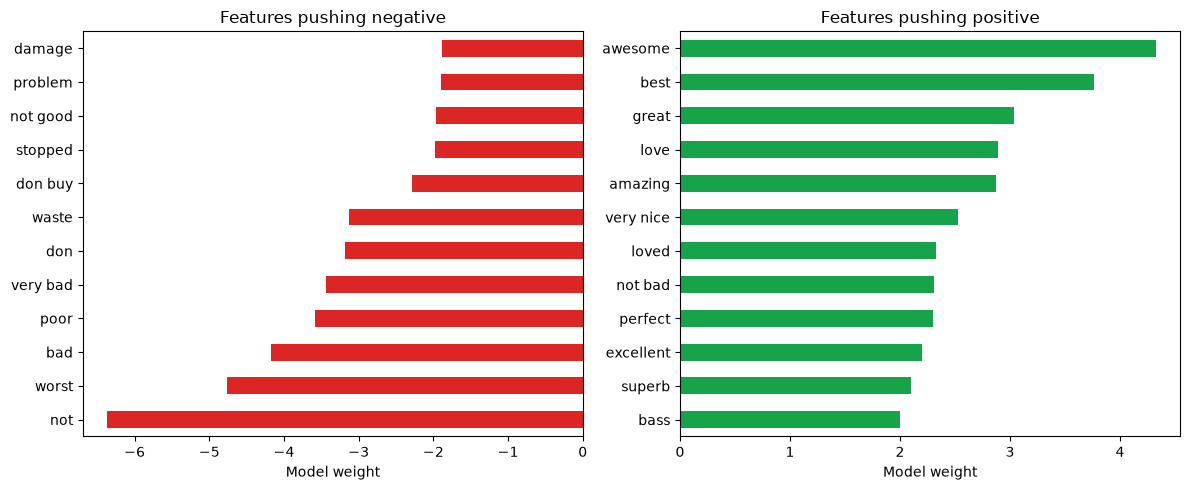

In [8]:
vectorizer = sentiment_model.named_steps["tfidf"]
classifier = sentiment_model.named_steps["classifier"]
feature_names = vectorizer.get_feature_names_out()
weights = classifier.coef_[0]
top_n = 12

most_negative = pd.Series(weights, index=feature_names).nsmallest(top_n)
most_positive = pd.Series(weights, index=feature_names).nlargest(top_n)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
most_negative.sort_values().plot.barh(ax=axes[0], color="#DC2626")
axes[0].set(title="Features pushing negative", xlabel="Model weight")
most_positive.sort_values().plot.barh(ax=axes[1], color="#16A34A")
axes[1].set(title="Features pushing positive", xlabel="Model weight")
plt.tight_layout()
plt.show()


## 9. Try fresh reviews

The helper returns the predicted label and the model's positive probability. Treat it as a score, not as a guaranteed understanding of a customer's intent.


In [9]:
def predict_review_sentiment(texts: list[str]) -> pd.DataFrame:
    cleaned = [clean_review(text) for text in texts]
    positive_probability = sentiment_model.predict_proba(cleaned)[:, 1]
    return pd.DataFrame(
        {
            "review": texts,
            "prediction": np.where(positive_probability >= 0.5, "positive", "negative"),
            "positive_probability": positive_probability.round(3),
        }
    )

predict_review_sentiment(
    [
        "The battery lasts all day and the sound is excellent.",
        "Stopped working after two days. Very disappointed.",
        "The product is okay, but delivery was late.",
    ]
)


,review,prediction,positive_probability
0,The battery lasts all day and the sound is exc...,positive,0.765
1,Stopped working after two days. Very disappoin...,negative,0.083
2,"The product is okay, but delivery was late.",negative,0.438


## Try next

Add a neutral class, compare this model with a decision tree, or inspect incorrectly classified reviews. Customer-review models should be monitored because product language changes over time.
